## Aspect data


In [1]:

import geopandas as gpd
import pandas as pd


#Read in shapefile tags
ahp = gpd.read_file("/fs9/eliviau/hex2vec_project/clean_data/data/aspect_tags") #specify which tags to use


In [2]:
ahp.head()

,feature_id,aspect,geometry
0,0,315,"POLYGON ((148.74167 45.55, 148.75 45.55, 148.7..."
1,1,331,"POLYGON ((148.75 45.55, 148.75833 45.55, 148.7..."
2,2,4,"POLYGON ((148.75833 45.55, 148.76667 45.55, 14..."
3,3,353,"POLYGON ((148.76667 45.55, 148.775 45.55, 148...."
4,4,348,"POLYGON ((148.775 45.55, 148.78333 45.55, 148...."


In [3]:
ahp["aspect"].unique()

array([  315,   331,     4,   353,   348,    10,    25,   355,     0,
          45,   330,   343,   351,    11,   352,   319,     3,   339,
         359,     9,    13,   357,     7,    28,   337,   356,     8,
          27,   354,   349,   342,   341,   344,    14,    15,   312,
         340, -9999,   323,     6,   347,    19,    34,    18,    16,
         336,    37,    31,   306,   307,   326,   346,   345,   328,
         321,    42,   309,   320,   317,    32,    43,    17,    12,
          24,    49,   327,   338,    63,   288,   293,   287,   281,
         294,   305,   302,   280,   263,   264,    50,   310,   270,
         282,   241,   231,    58,    62,    30,     5,   324,   318,
          29,    41,    57,    79,   286,   255,   232,   233,   254,
         243,   242,   268,   223,   238,    60,   358,    55,    38,
          53,   329,    71,   325,    52,    39,    67,    73,   297,
         291,   292,   283,   245,   333,   179,   175,    35,    68,
          65,    77,

In [4]:
from srai.regionalizers import geocode_to_region_gdf

# Step 1: Get the boundary for Yamagata prefecture
area = geocode_to_region_gdf("Hokkaido, Japan")
area.crs  # should return EPSG:4326

/home/eliviau/miniconda3/envs/hex2vec_env/lib/python3.9/site-packages/networkx/utils/backends.py:135: RuntimeWarning: networkx backend defined more than once: nx-loopback
  backends.update(_get_backends("networkx.backends"))


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [5]:
area.head()

,geometry
region_id,
"Hokkaido Prefecture, Japan","POLYGON ((139.06728 41.51453, 139.06751 41.506..."


In [6]:
from srai.regionalizers import H3Regionalizer

# Step 2: Create H3 hexagons for Yamagata
regionalizer = H3Regionalizer(resolution=7)  # resolution 9 = ~500m hexes
regions = regionalizer.transform(area)

regions.head()

,geometry
region_id,
872eab348ffffff,"POLYGON ((142.62893 45.19222, 142.6248 45.2044..."
872e13259ffffff,"POLYGON ((144.06789 42.7705, 144.06411 42.7829..."
872ead6b4ffffff,"POLYGON ((143.82089 44.01047, 143.817 44.02286..."
872e1b7b5ffffff,"POLYGON ((141.21395 43.28425, 141.20973 43.296..."
872e1e0a6ffffff,"POLYGON ((143.6013 42.55274, 143.59747 42.5652..."


In [7]:
regions.shape

(28902, 1)

step 3 : join 

In [8]:
from srai.joiners import IntersectionJoiner

# Make sure CRS matches!
ahp = ahp.to_crs(regions.crs)

# Step 3: Use IntersectionJoiner to match land cover to hexagons
joiner = IntersectionJoiner()
joined = joiner.transform(regions, ahp)

# Preview the result
joined.head()


,
region_id,feature_id
872e8db6effffff,30
872e8db63ffffff,31
872e8db6effffff,31
872e8db45ffffff,31
872e8db63ffffff,32


In [9]:
joined.shape

(253941, 0)

In [10]:
# Bring region_id back as a column
joined = joined.reset_index()

# Now merge safely
joined_with_tags = joined.merge(
    ahp[["feature_id", "aspect"]],
    on="feature_id",
    how="left"
)

In [11]:
joined_with_tags.head()

,region_id,feature_id,aspect
0,872e8db6effffff,30,315
1,872e8db63ffffff,31,337
2,872e8db6effffff,31,337
3,872e8db45ffffff,31,337
4,872e8db63ffffff,32,356


In [12]:
def aspect_score(aspect_deg):
    if (aspect_deg >= 337.5 or aspect_deg < 22.5):
        return 0  # North
    elif 22.5 <= aspect_deg < 67.5:
        return 0  # Northeast
    elif 67.5 <= aspect_deg < 112.5:
        return 1  # East
    elif 112.5 <= aspect_deg < 157.5:
        return 6  # Southeast
    elif 157.5 <= aspect_deg < 202.5:
        return 10  # South
    elif 202.5 <= aspect_deg < 247.5:
        return 6  # Southwest
    elif 247.5 <= aspect_deg < 292.5:
        return 1  # West
    elif 292.5 <= aspect_deg < 337.5:
        return 0  # Northwest
    else:
        return None  # missing or invalid
    
    

In [13]:
ahp["ahp_score"] = ahp["aspect"].apply(aspect_score)


In [14]:
ahp.head()

,feature_id,aspect,geometry,ahp_score
0,0,315,"POLYGON ((148.74167 45.55, 148.75 45.55, 148.7...",0
1,1,331,"POLYGON ((148.75 45.55, 148.75833 45.55, 148.7...",0
2,2,4,"POLYGON ((148.75833 45.55, 148.76667 45.55, 14...",0
3,3,353,"POLYGON ((148.76667 45.55, 148.775 45.55, 148....",0
4,4,348,"POLYGON ((148.775 45.55, 148.78333 45.55, 148....",0


In [15]:
joined_with_tags["ahp_score"] = joined_with_tags["aspect"].map(aspect_score)


In [16]:
hex_scores = joined_with_tags.groupby("region_id")["ahp_score"].mean().reset_index()
hex_scores.columns = ["region_id", "ahp_score"]


In [17]:
# Merge scores into hexagon GeoDataFrame
regions_scored = regions.merge(hex_scores, on="region_id", how="left")


In [18]:
regions_scored.head(30)

,region_id,geometry,ahp_score
0,872ead66affffff,"POLYGON ((143.4321 43.80835, 143.42817 43.8207...",1.071429
1,872e134eaffffff,"POLYGON ((144.99885 43.15934, 144.99518 43.171...",5.000000
2,872ef0588ffffff,"POLYGON ((140.96606 45.07837, 140.96169 45.090...",1.000000
3,872ea950affffff,"POLYGON ((143.29103 44.53006, 143.28703 44.542...",1.000000
4,872ef2a90ffffff,"POLYGON ((140.70522 45.5837, 140.70078 45.5956...",1.000000
5,872ea974affffff,"POLYGON ((142.55605 44.5054, 142.55195 44.5176...",0.176471
6,872ead94dffffff,"POLYGON ((143.96333 42.96771, 143.95953 42.980...",4.928571
7,872ea90adffffff,"POLYGON ((142.91086 44.34767, 142.90682 44.359...",6.823529
8,872e1b145ffffff,"POLYGON ((141.12779 42.72896, 141.1236 42.7411...",3.687500
9,872e194aeffffff,"POLYGON ((141.15846 42.30002, 141.1543 42.3122...",1.000000


In [20]:
#regions_scored save to output
regions_scored.to_file("/fs9/eliviau/hex2vec_project/Eli_test/ELIS_PROJECT/MCDM_project/outputs and maps/hokkaido_ahp_aspecreso7.geojson", driver="GeoJSON")

In [19]:
from srai.plotting import plot_numeric_data

#remettre le index 
regions_scored = regions_scored.set_index("region_id")

m = plot_numeric_data(regions_scored, "ahp_score", colormap="Oranges", opacity=0.6)
m.save("aspect_Hokkaido_map.html")


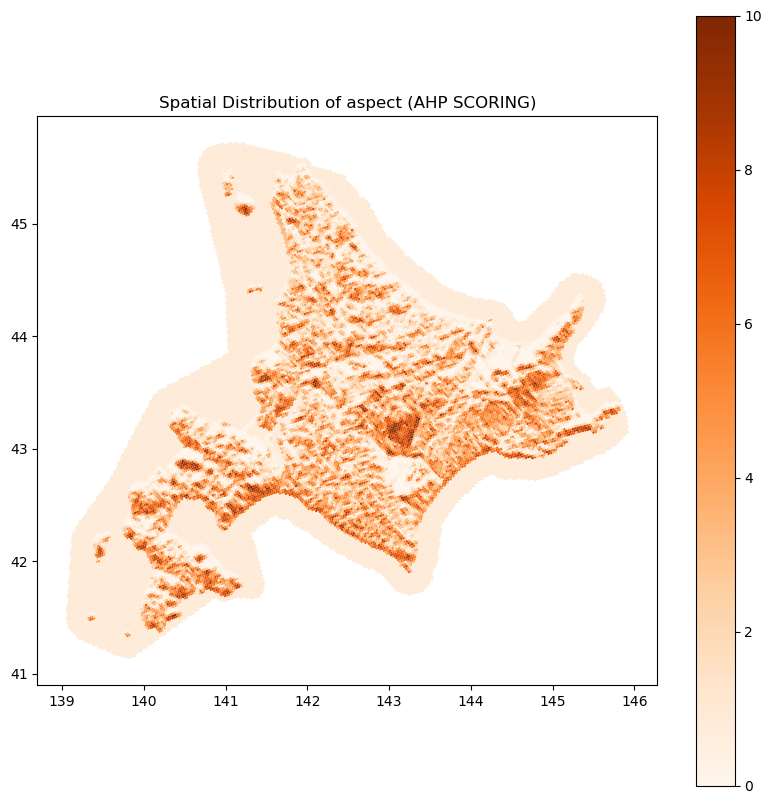

In [20]:
#other map 

#other quickmap 
# If you still have 'regions' geodataframe loaded:


from matplotlib import pyplot as plt


regions_scored.plot(
    column='ahp_score',
    cmap='Oranges',
    legend=True,
    figsize=(10,10)
)
plt.title("Spatial Distribution of aspect (AHP SCORING)")
plt.show()


/tmp/ipykernel_50975/247323038.py:39: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


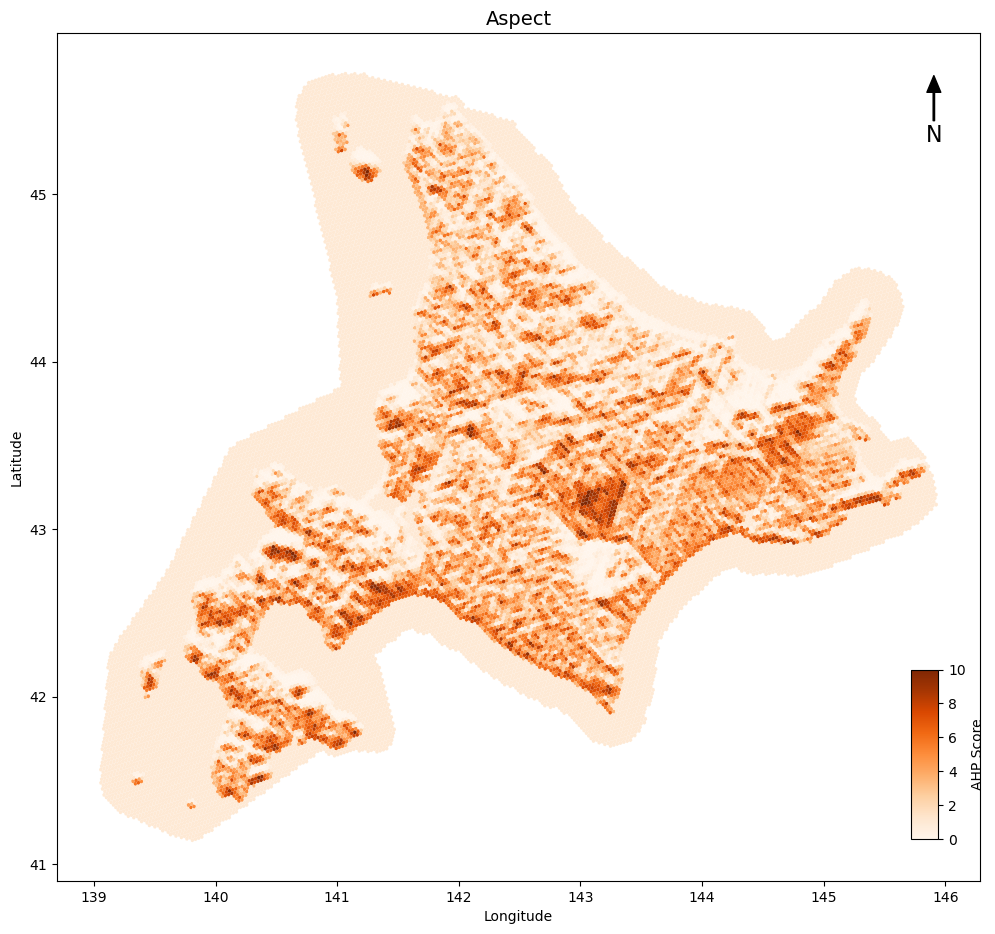

In [19]:
import geopandas as gpd
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


# 1. Create plot
fig, ax = plt.subplots(figsize=(10, 10))

# 2. Plot main map
main_plot = regions_scored.plot(
    column='ahp_score',
    cmap='Oranges',
    legend=False,  # We'll add a custom one
    ax=ax,
    edgecolor='none'
)

# 3. Add colorbar INSIDE the plot area
sm = plt.cm.ScalarMappable(cmap='Oranges', norm=plt.Normalize(vmin=regions_scored['ahp_score'].min(), vmax=regions_scored['ahp_score'].max()))
sm._A = []

cax = inset_axes(ax, width="3%", height="20%", loc='lower right', borderpad=3)  # Adjust size/position here
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label("AHP Score")

# 4. Coordinate grid and title
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Aspect", fontsize=14)

# Add north arrow but arrow shorter
ax.annotate('N',
            xy=(0.95, 0.95), xytext=(0.95, 0.88),
            xycoords='axes fraction',
            ha='center', va='center',
            fontsize=16,
            arrowprops=dict(facecolor='black', width=1, headwidth=10)) 

plt.tight_layout()
plt.show()
